In [20]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

path = '/home/mina-joojoo/Desktop/tool_wearing/'
dataset = pd.read_csv(path + 'correlated_dataset.csv')

In [21]:
from sklearn.model_selection import train_test_split
rest = dataset[dataset['tool'] != 8]
test_set = dataset[dataset['tool'] == 8]
train_set, validation_set = train_test_split(rest,random_state=42,test_size=0.2)
train_set = train_set.drop('tool', axis=1)
validation_set = validation_set.drop('tool', axis=1)
test_set = test_set.drop('tool', axis=1)

In [22]:
X = train_set.drop(columns=["VB"])
y = train_set["VB"].values
mask = ~X.isna()
mask = mask.astype(float)
X = X.fillna(0)

X_validation = validation_set.drop(columns=["VB"])
y_validation = validation_set["VB"].values
mask_validation = ~X_validation.isna()
mask_validation = mask_validation.astype(float)
X_validation = X_validation.fillna(0)

X_validation_tensor = torch.tensor(X_validation.values, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation, dtype=torch.float32)
mask_validation_tensor = torch.tensor(mask_validation.values, dtype=torch.float32)

X_test = test_set.drop(columns=["VB"])
y_test = test_set["VB"].values
mask_test = ~X_test.isna()
mask_test = mask_test.astype(float)
X_test = X_test.fillna(0)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
mask_test_tensor = torch.tensor(mask_test.values, dtype=torch.float32)

In [23]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
y_pred = model.predict(X_test)


In [25]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.03938990256175383
RMSE: 0.04506924005413044
R2: 0.9411591681695548


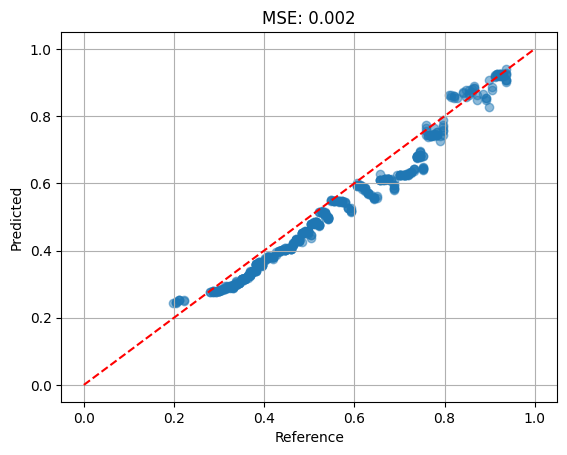

In [26]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("Reference")
plt.ylabel("Predicted")
plt.title(f'MSE: {mse:.3f}')
plt.grid()
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Test MSE:", mse)

Test MSE: 0.0019833081447719406
